# Freight Rate — Exploratory Data Analysis

Predict `posted_rate` for Nov–Dec 2025, trained on Jan–Oct 2025. The split is by time.

This notebook is **analysis only**. Feature engineering, selection and modelling live in
`src/` and MLflow — see the README.

1. Load
2. Column audit
3. Correlation (raw)
4. Rate per mile
5. Target distribution
6. Distance distribution
7. Time influence
8. Feature evidence

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, "..")
from src import features as F

DATA = Path("..") / "data" / "input"
TARGET = "posted_rate"
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

## 1. Load

Three files. Only the training file has the target.

In [2]:
train = F.load_dataset(DATA / "train-test.csv")
validation = F.load_dataset(DATA / "validation.csv")
december = F.load_dataset(DATA / "december-chart-inputs.csv")

for name, frame in [("train", train), ("validation", validation), ("december", december)]:
    print(f"{name:11s}: {frame.shape[0]:>6,} rows   {frame['date'].min():%Y-%m-%d} to {frame['date'].max():%Y-%m-%d}")

train      : 48,000 rows   2025-01-01 to 2025-10-31
validation : 12,000 rows   2025-11-01 to 2025-12-31
december   :     31 rows   2025-12-01 to 2025-12-31


Train and validation do not overlap in time — so a random split is invalid.

In [3]:
train.head(5)

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


## 2. Column audit

In [4]:
def column_overview(frame):
    out = pd.DataFrame({"dtype": frame.dtypes.astype(str),
                        "missing": frame.isna().sum(),
                        "unique": frame.nunique(dropna=True)})
    out["missing_pct"] = (out["missing"] / len(frame) * 100).round(2)
    return out


column_overview(train)

,dtype,missing,unique,missing_pct
load_id,object,0,48000,0.00
pickup,object,0,64,0.00
delivery,object,0,64,0.00
pickup_lat,float64,0,64,0.00
pickup_lon,float64,0,63,0.00
delivery_lat,float64,0,64,0.00
delivery_lon,float64,0,63,0.00
distance,float64,0,21204,0.00
equipment,object,0,3,0.00
weight,float64,300,23678,0.62


In [5]:
pd.Series({
    "negative weight": int((train["weight"] < 0).sum()),
    "missing weight": int(train["weight"].isna().sum()),
    "missing market_index": int(train["market_index"].isna().sum()),
}, name="count")

negative weight         292
missing weight          300
missing market_index    374
Name: count, dtype: int64

`weight` has negative values (sign errors) and a few gaps. Cleaned in `src.features`:
absolute value, then median imputation.

## 3. Correlation (raw)

Pearson sees linear links only.

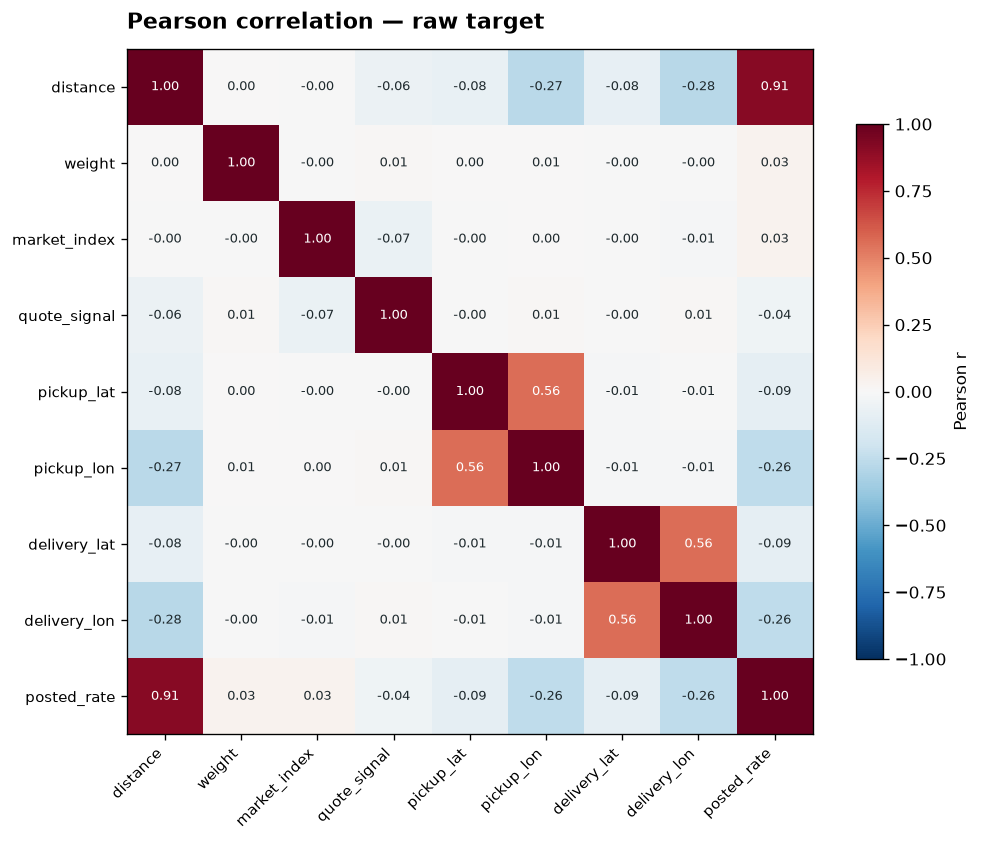

In [6]:
def plot_corr(matrix, title):
    labels = list(matrix.columns)
    fig, ax = plt.subplots(figsize=(8.5, 7.0), dpi=120)
    im = ax.imshow(matrix.to_numpy(), cmap="RdBu_r", vmin=-1.0, vmax=1.0)
    ax.set_xticks(range(len(labels)), labels, rotation=45, ha="right", fontsize=9)
    ax.set_yticks(range(len(labels)), labels, fontsize=9)
    for r in range(len(labels)):
        for c in range(len(labels)):
            v = matrix.iat[r, c]
            ax.text(c, r, f"{v:.2f}", ha="center", va="center", fontsize=8,
                    color="white" if abs(v) > 0.55 else "#1F2A2E")
    ax.set_title(title, loc="left", fontsize=13, fontweight="bold", pad=12)
    fig.colorbar(im, ax=ax, shrink=0.78, label="Pearson r")
    fig.tight_layout(); plt.show()


cols = ["distance", "weight", "market_index", "quote_signal",
        "pickup_lat", "pickup_lon", "delivery_lat", "delivery_lon", TARGET]
plot_corr(train[cols].corr(), "Pearson correlation — raw target")

`distance` dominates (~0.91) and hides everything else. We remove it next.

## 4. Rate per mile

Model `posted_rate / distance` so distance stops hiding the rest.

In [7]:
def compare_targets(frame, columns):
    per_mile = frame[TARGET] / frame["distance"]
    rows = {c: {"vs posted_rate": frame[c].corr(frame[TARGET]),
                "vs rate_per_mile": frame[c].corr(per_mile),
                "spearman": frame[c].corr(per_mile, method="spearman")}
            for c in columns}
    return pd.DataFrame(rows).T.round(3)


compare_targets(train, ["distance", "weight", "market_index", "quote_signal",
                        "pickup_lon", "delivery_lon"])

,vs posted_rate,vs rate_per_mile,spearman
distance,0.909,-0.335,-0.736
weight,0.035,0.075,0.196
market_index,0.034,0.083,0.180
quote_signal,-0.040,0.049,0.091
pickup_lon,-0.255,0.055,0.050
delivery_lon,-0.257,0.055,0.050


`distance` drops to −0.34, but Spearman is −0.74: the link is real but **curved**.
The rest stays weak — signal is non-linear.

## 5. Target distribution

Pick the scale to model on.

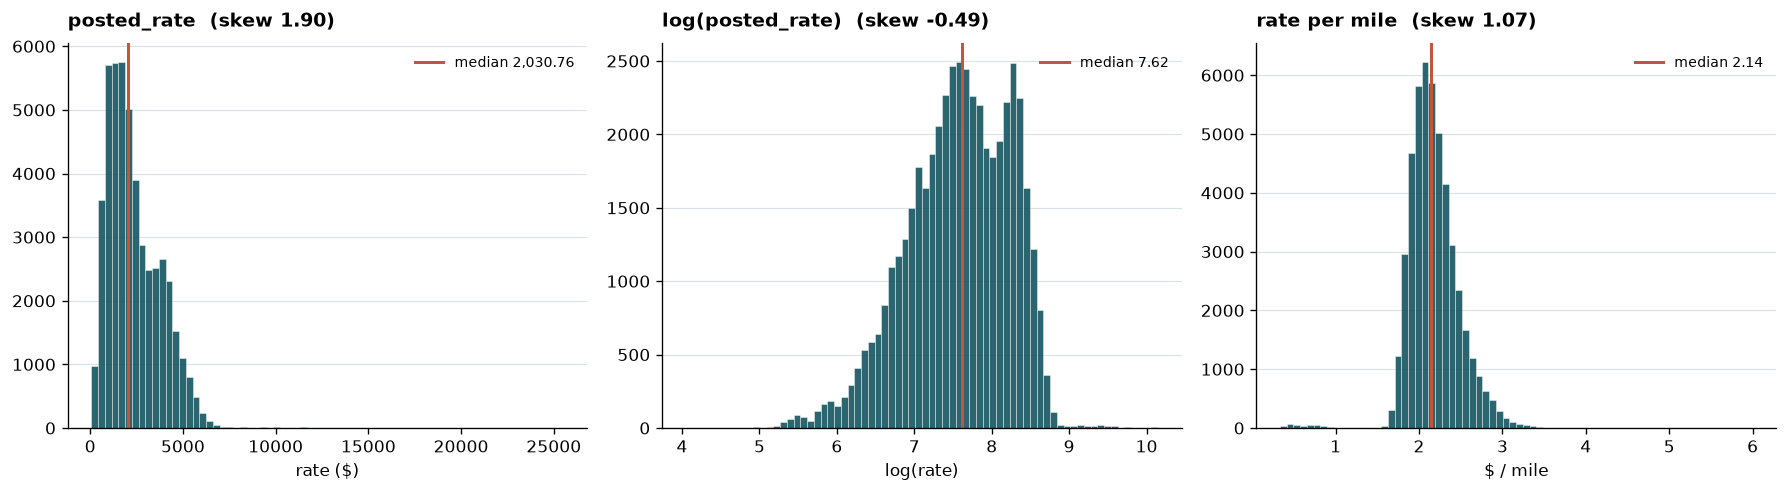

In [8]:
def plot_target(frame):
    per_mile = frame[TARGET] / frame["distance"]
    panels = [(frame[TARGET], "posted_rate", "rate ($)"),
              (np.log(frame[TARGET]), "log(posted_rate)", "log(rate)"),
              (per_mile[per_mile < 6], "rate per mile", "$ / mile")]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), dpi=120)
    for ax, (values, title, xlabel) in zip(axes, panels):
        ax.hist(values, bins=70, color="#064A56", alpha=0.85, edgecolor="white", linewidth=0.3)
        ax.axvline(np.median(values), color="#C4553B", lw=1.8, label=f"median {np.median(values):,.2f}")
        ax.set_title(f"{title}  (skew {pd.Series(values).skew():.2f})",
                     loc="left", fontsize=11.5, fontweight="bold", pad=10)
        ax.set_xlabel(xlabel); ax.legend(fontsize=8.5, frameon=False)
        ax.grid(axis="y", color="#D9E2E4", lw=0.7); ax.set_axisbelow(True)
        ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout(); plt.show()


plot_target(train)

In [9]:
def summary_stats(frame):
    def describe(s):
        return {"min": s.min(), "1%": s.quantile(0.01), "median": s.median(),
                "mean": s.mean(), "99%": s.quantile(0.99), "max": s.max()}
    per_mile = frame[TARGET] / frame["distance"]
    return pd.DataFrame({"posted_rate ($)": describe(frame[TARGET]),
                         "rate_per_mile ($/mi)": describe(per_mile)}).T.round(2)


summary_stats(train)

,min,1%,median,mean,99%,max
posted_rate ($),57.22,327.17,2030.76,2373.98,5972.83,25533.00
rate_per_mile ($/mi),0.33,1.67,2.15,2.22,3.18,14.13


Raw skew 1.90 (long tail to \$25k); log brings it to −0.49. The metric is relative,
so we model `log(posted_rate / distance)`.

## 6. Distance distribution

Band edges from quantiles, not round numbers — so each band holds ~1/6 of the loads.

quantile edges: [0, 431, 688, 953, 1323, 1968, 'inf']


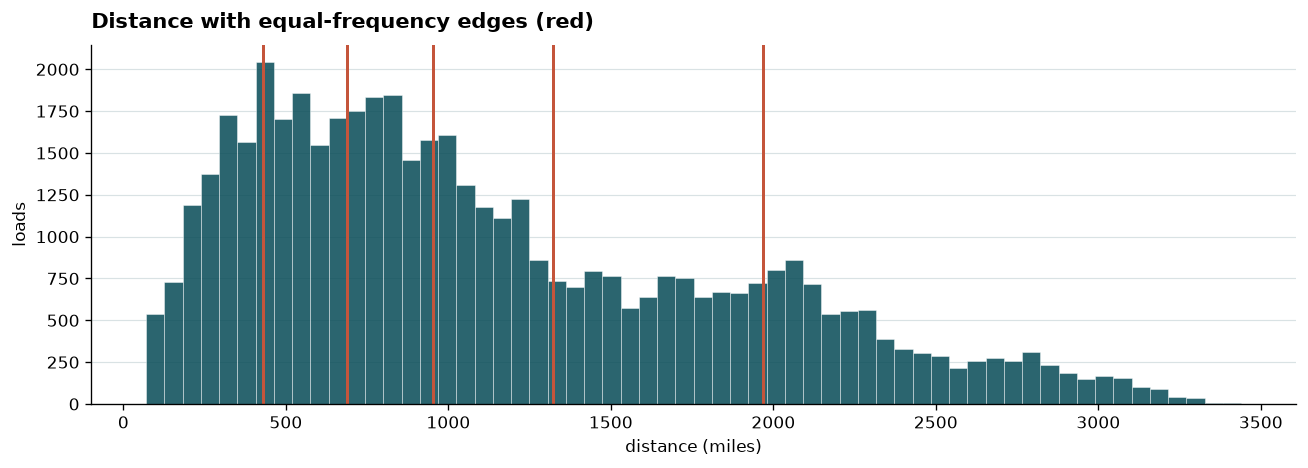

In [10]:
edges = F.distance_bin_edges(train, n_bins=6)
print("quantile edges:", [round(e) if np.isfinite(e) else "inf" for e in edges])

fig, ax = plt.subplots(figsize=(11, 4.0), dpi=120)
ax.hist(train["distance"], bins=60, color="#064A56", alpha=0.85, edgecolor="white", linewidth=0.3)
for e in edges[1:-1]:
    ax.axvline(e, color="#C4553B", lw=1.8)
ax.set_title("Distance with equal-frequency edges (red)", loc="left", fontsize=12.5, fontweight="bold", pad=10)
ax.set_xlabel("distance (miles)"); ax.set_ylabel("loads")
ax.grid(axis="y", color="#D9E2E4", lw=0.7); ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout(); plt.show()

In [11]:
pd.DataFrame({
    "arbitrary": pd.cut(train["distance"], [0, 300, 600, 1000, 1500, 2500, np.inf]).value_counts().sort_index().values,
    "quantile":  pd.cut(train["distance"], edges).value_counts().sort_index().values,
}, index=F.DISTANCE_LABELS)

,arbitrary,quantile
very_short,3983,7988
short,9444,8003
medium,11918,8006
long,9008,8011
very_long,10962,7993
extreme,2685,7999


Round-number edges swing from ~2,700 to ~11,900 per band. Quantile edges sit near
8,000 each.

## 7. Time influence

Two cycles: the week and the year.

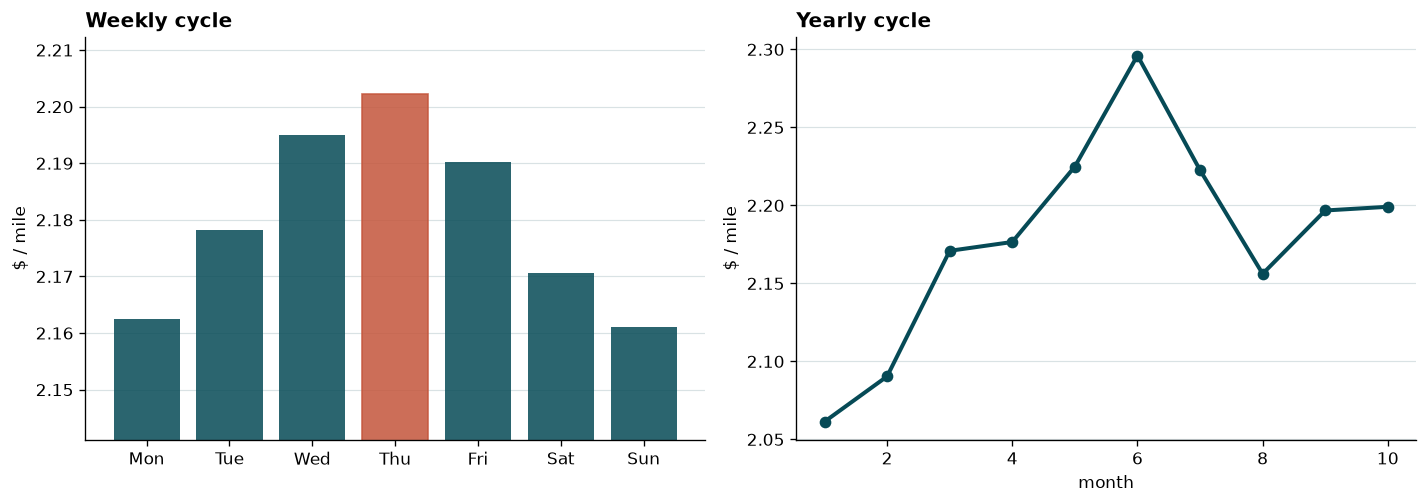

In [12]:
def plot_time(frame):
    df = frame.copy()
    df["rpm"] = df[TARGET] / df["distance"]
    df = df[df["rpm"] < 6]
    fig, ax = plt.subplots(1, 2, figsize=(12, 4.3), dpi=120)

    weekly = df.groupby(df["date"].dt.dayofweek)["rpm"].mean()
    bars = ax[0].bar(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"], weekly.values, color="#064A56", alpha=0.85)
    bars[int(weekly.idxmax())].set_color("#C4553B")
    ax[0].set_ylim(weekly.min() - 0.02, weekly.max() + 0.01)
    ax[0].set_title("Weekly cycle", loc="left", fontsize=12, fontweight="bold")

    monthly = df.groupby(df["date"].dt.month)["rpm"].mean()
    ax[1].plot(monthly.index, monthly.values, color="#064A56", lw=2.4, marker="o")
    ax[1].set_title("Yearly cycle", loc="left", fontsize=12, fontweight="bold")
    ax[1].set_xlabel("month")

    for a in ax:
        a.set_ylabel("$ / mile"); a.grid(axis="y", color="#D9E2E4", lw=0.7); a.set_axisbelow(True)
        a.spines[["top", "right"]].set_visible(False)
    fig.tight_layout(); plt.show()


plot_time(train)

Mid-week is dearer, weekend cheaper. The rate climbs to summer and falls in autumn.

## 8. Feature evidence

Each feature comes from a check, not a guess.

**Equipment.**

In [13]:
train.assign(rpm=train[TARGET] / train["distance"]) \
    .groupby("equipment")["rpm"].agg(["mean", "count"]).round(3)

,mean,count
equipment,,
Dry Van,2.115,27202
Flatbed,2.295,8753
Reefer,2.383,12045


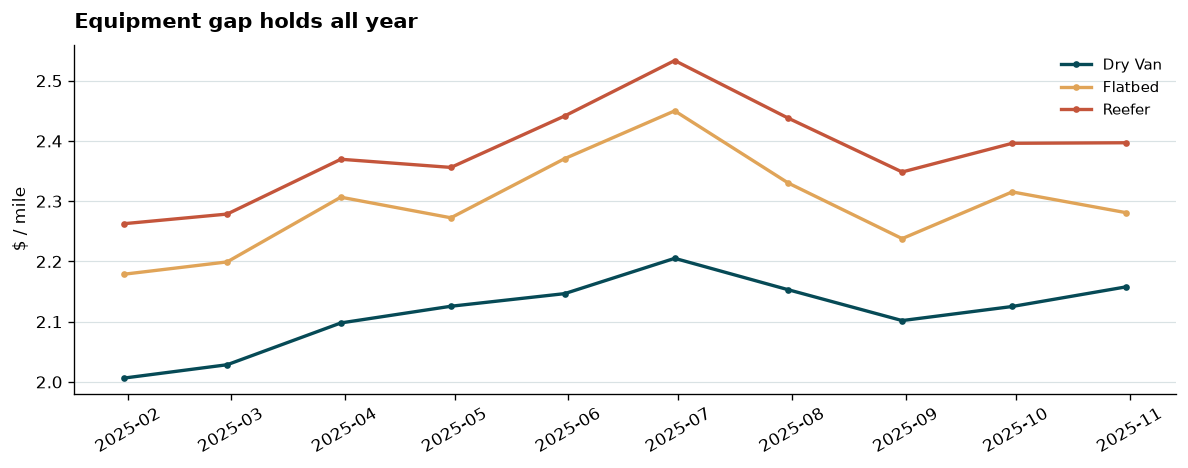

In [14]:
df = train.assign(rpm=train[TARGET] / train["distance"])
fig, ax = plt.subplots(figsize=(10, 4.0), dpi=120)
for eq, c in zip(["Dry Van", "Flatbed", "Reefer"], ["#064A56", "#E0A458", "#C4553B"]):
    s = df[df["equipment"] == eq].set_index("date")["rpm"].resample("ME").mean()
    ax.plot(s.index, s.values, lw=2.0, marker="o", ms=3, color=c, label=eq)
ax.set_title("Equipment gap holds all year", loc="left", fontsize=12.5, fontweight="bold", pad=10)
ax.set_ylabel("$ / mile"); ax.legend(fontsize=9, frameon=False); ax.tick_params(axis="x", rotation=30)
ax.grid(axis="y", color="#D9E2E4", lw=0.7); ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout(); plt.show()

Reefer dearest, Dry Van cheapest — a clear, ordered gap that holds all year, so
equipment is a stable feature.

**City → coordinate.**

In [15]:
check = train.groupby("pickup")[["pickup_lat", "pickup_lon"]].nunique()
print("cities:", len(check),
      "| with >1 latitude:", int((check["pickup_lat"] > 1).sum()),
      "| with >1 longitude:", int((check["pickup_lon"] > 1).sum()))

cities: 64 | with >1 latitude: 0 | with >1 longitude: 0


Each city has exactly one coordinate — so coordinates carry the city as a number the
tree can split into regions.

In [16]:
unknown = sorted(set(validation["pickup"]) - set(train["pickup"]))
n = validation["pickup"].isin(unknown).sum()
print(f"cities only in validation: {len(unknown)} -> {unknown}")
print(f"loads affected: {n} ({n / len(validation) * 100:.1f}%)")

cities only in validation: 8 -> ['Allentown', 'Charlotte', 'Chicago', 'Jackson', 'Knoxville', 'Laredo', 'Norfolk', 'San Diego']
loads affected: 725 (6.0%)


8 cities appear only in validation (~6% of loads). Coordinates place them in a known
region; names could not. This is why geography uses lat/lon.

## 9. Why we drop market_index and quote_signal

First reason: the December file does not have them, so a feature using them cannot produce
the chart. Second: their signal is weak anyway.

In [17]:
pd.DataFrame({
    "in train": [c in train.columns for c in ["market_index", "quote_signal"]],
    "in validation": [c in validation.columns for c in ["market_index", "quote_signal"]],
    "in december": [c in december.columns for c in ["market_index", "quote_signal"]],
}, index=["market_index", "quote_signal"])

,in train,in validation,in december
market_index,True,True,False
quote_signal,True,True,False


In [18]:
df = train.dropna(subset=["market_index"]).copy()
df["rpm"] = df[TARGET] / df["distance"]
daily = df.groupby("date").agg(rpm=("rpm", "mean"), mi=("market_index", "mean"))
print(f"market_index vs rate_per_mile  — per row: {df['market_index'].corr(df['rpm']):.3f}"
      f"   per day: {daily['mi'].corr(daily['rpm']):.3f}")
print(f"quote_signal vs rate_per_mile  — {df['quote_signal'].corr(df['rpm']):.3f}"
      f"   but quote_signal x distance vs price: {(df['quote_signal'] * df['distance']).corr(df[TARGET]):.3f}")

market_index vs rate_per_mile  — per row: 0.083   per day: 0.573
quote_signal vs rate_per_mile  — 0.049   but quote_signal x distance vs price: 0.898


`market_index` is near-zero per row but ~0.57 once averaged per day — a daily index, not
a per-load signal. `quote_signal` only correlates through distance (an artefact). Even if
they were available, they add little. Absent from December, they are out.

## 10. Rate-per-mile outliers

A few loads have extreme per-mile rates.

In [19]:
rpm = train[TARGET] / train["distance"]
extreme = rpm > 5
print(f"{extreme.sum()} loads over $5/mile ({extreme.mean() * 100:.2f}%), up to {rpm.max():.1f}")
print(f"median rate_per_mile: {rpm.median():.2f}")

317 loads over $5/mile (0.66%), up to 14.1
median rate_per_mile: 2.15


~0.7% of loads sit far above the rest (up to 14 \$/mile). These rare extremes are why
we model on the log scale and impute with the median, not the mean.

## 11. Geography

Rate per mile is not uniform across the country. Averaged per pickup city, a regional
pattern appears.

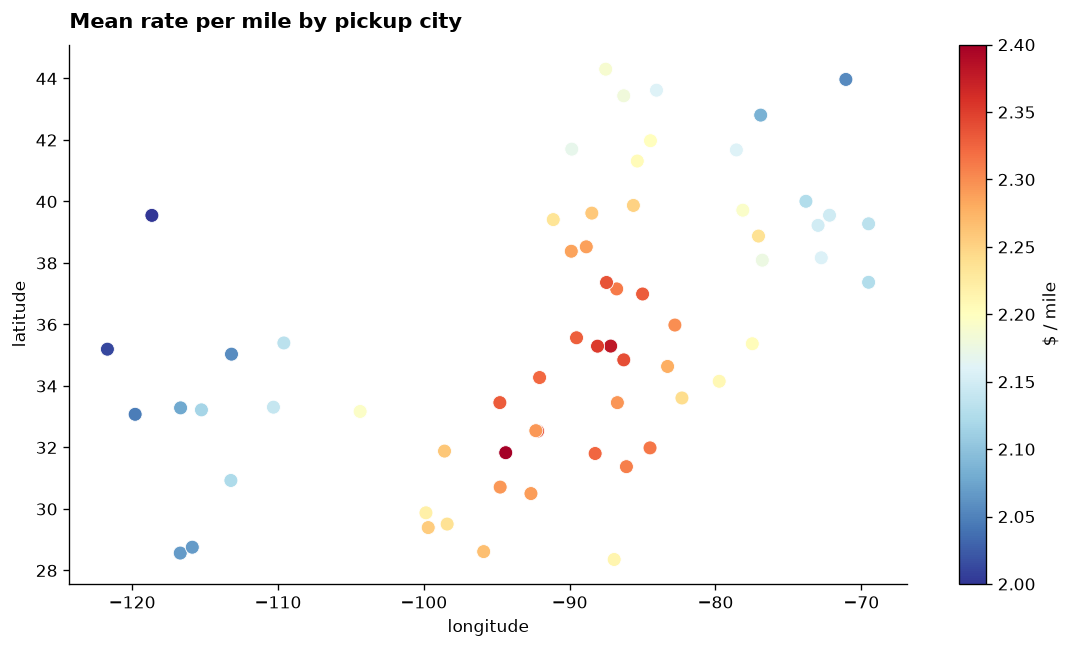

In [20]:
df = train.assign(rpm=train[TARGET] / train["distance"])
city = df.groupby("pickup").agg(lat=("pickup_lat", "first"), lon=("pickup_lon", "first"),
                                rpm=("rpm", "mean"))
fig, ax = plt.subplots(figsize=(9.5, 5.5), dpi=120)
sc = ax.scatter(city["lon"], city["lat"], c=city["rpm"], cmap="RdYlBu_r",
                s=70, vmin=2.0, vmax=2.4, edgecolor="white", linewidth=0.5)
ax.set_title("Mean rate per mile by pickup city", loc="left", fontsize=12.5, fontweight="bold", pad=10)
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
fig.colorbar(sc, ax=ax, label="$ / mile")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout(); plt.show()

In [21]:
# same signal as a table: rate by broad region
df["lon_band"] = pd.cut(df["pickup_lon"], [-125, -100, -85, -65], labels=["West", "Central", "East"])
df["lat_band"] = pd.cut(df["pickup_lat"], [24, 37, 50], labels=["South", "North"])
df.pivot_table("rpm", "lat_band", "lon_band", observed=True).round(3)

lon_band,West,Central,East
lat_band,,,
South,2.095,2.301,2.275
North,1.979,2.241,2.145


The West is cheapest, the Central–South dearest — a real regional spread (~0.45 \$/mile
between the cheapest and dearest cities). Coordinates carry this signal; city names could
not, and the tree can split on lat/lon.

## 12. Data quality — negative weights

The negative weights are sign errors, not a different population.

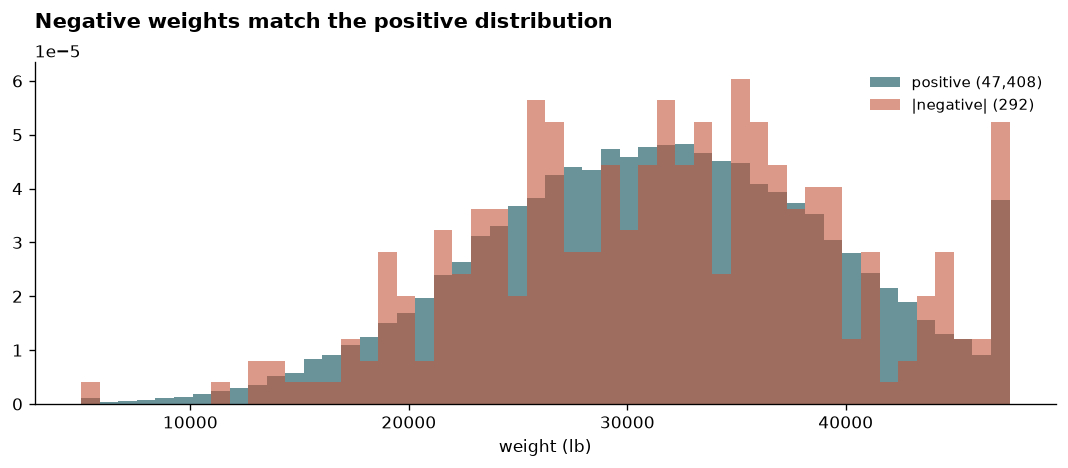

In [22]:
pos = train.loc[train["weight"] > 0, "weight"]
neg = train.loc[train["weight"] < 0, "weight"].abs()
fig, ax = plt.subplots(figsize=(9, 4), dpi=120)
ax.hist(pos, bins=50, alpha=0.6, density=True, color="#064A56", label=f"positive ({len(pos):,})")
ax.hist(neg, bins=50, alpha=0.6, density=True, color="#C4553B", label=f"|negative| ({len(neg)})")
ax.set_title("Negative weights match the positive distribution", loc="left", fontsize=12.5, fontweight="bold", pad=10)
ax.set_xlabel("weight (lb)"); ax.legend(fontsize=9, frameon=False)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout(); plt.show()

 We take `abs()` and keep the rows.

---

Feature engineering, selection and modelling continue in `src/` and MLflow — see the README.